# Dimensionality Reduction Techniques

## Principal Component Analysis (PCA)

PCA is an *unsupervised* dimensionality reduction technique that transforms high-dimensional data into a new coordinate system where the axes (principal components) are ordered by the amount of variance they explain.  
怎麼樣的變數組合可以產生最大的變數分布範圍  那就是pc1 只考慮X  

### Key Concepts:
- PCA finds directions of maximum variance in the data
- Components are orthogonal to each other
- First component explains the most variance, followed by second, etc.
- Requires standardized data for optimal results

### Getting ready
To begin, we will load our toy dataset from scikit-learn. Version 1.5 of scikit-learn contains 6 datasets that are commonly used to illustrate various ML steps and features in the library. In this case, we will be using the Wine dataset.

In [1]:
import pandas as pd
from sklearn.datasets import load_wine

#Load dataset
wine = load_wine()
df_wine = pd.DataFrame(data=wine.data, columns=wine.feature_names)
target_wine = wine.target
display(df_wine.head(10))
target_wine

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

### How to do it...

We will load some additional libraries from scikit-learn as well as Matplotlib which is a commonly used Python library for data visualization. You’ll also notice that we are using the `Pipeline()` class to string together the data scaling preprocessing step with PCA. This will be a regular convention in this book so it’s best to get comfortable with it!

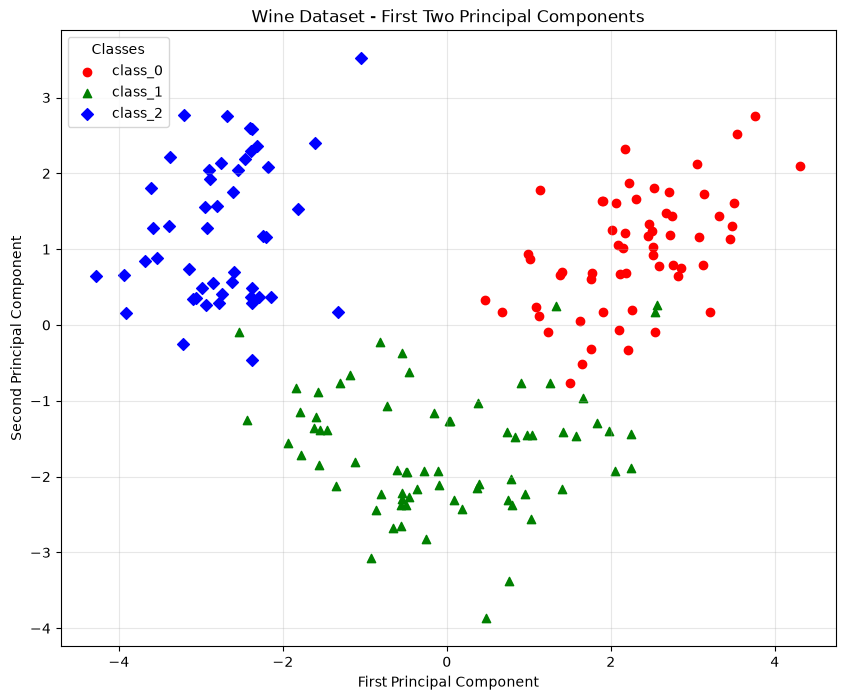

In [2]:
# Load libraries
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Create a pipeline for PCA
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Always scale before PCA
    ('pca', PCA(n_components=2))   # Reduce to 2 dimensions
])

# Fit and transform the data
X_pca = pca_pipeline.fit_transform(df_wine)

# Visualize the transformed data
plt.figure(figsize=(10, 8))
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# 這段碼的作用是根據葡萄酒資料集的不同分類（target），
# 以不同顏色（colors）和形狀（shapes）把經過PCA降維後的資料點(x, y)畫在平面上，便於觀察各類型之間的分布。
for i, (shape, color) in enumerate(zip(shapes, colors)):
    plt.scatter(X_pca[target_wine == i, 0], X_pca[target_wine == i, 1], 
                c=color, marker=shape, label=wine.target_names[i])
           
         

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - First Two Principal Components')
plt.legend(title="Classes")
plt.grid(True, alpha=0.3)
plt.show()

1.	Top Row: Original Standardized Features. The first two scatter plots display pairs of original standardized features before PCA: "Alcohol vs. Malic Acid" on the left and "Flavanoids vs. Proanthocyanins" on the right. Each data point is color-coded by wine class (class_0, class_1, class_2), with distinct markers for each class. The distribution shows overlap and separation among classes in the raw feature space.
2.	Bottom Row: PCA-Transformed Features. The bottom row shows the same features transformed using PCA, where data is reoriented along the first two principal components (PC1 and PC2). The arrows indicate the directions of PC1 and PC2, which capture the maximum variance in the data. PCA helps to better separate the wine classes by projecting the features into a lower-dimensional space with improved class distinction.  

經過PCA處理後的資料你會覺得不同類別的資料比較分成一群一群


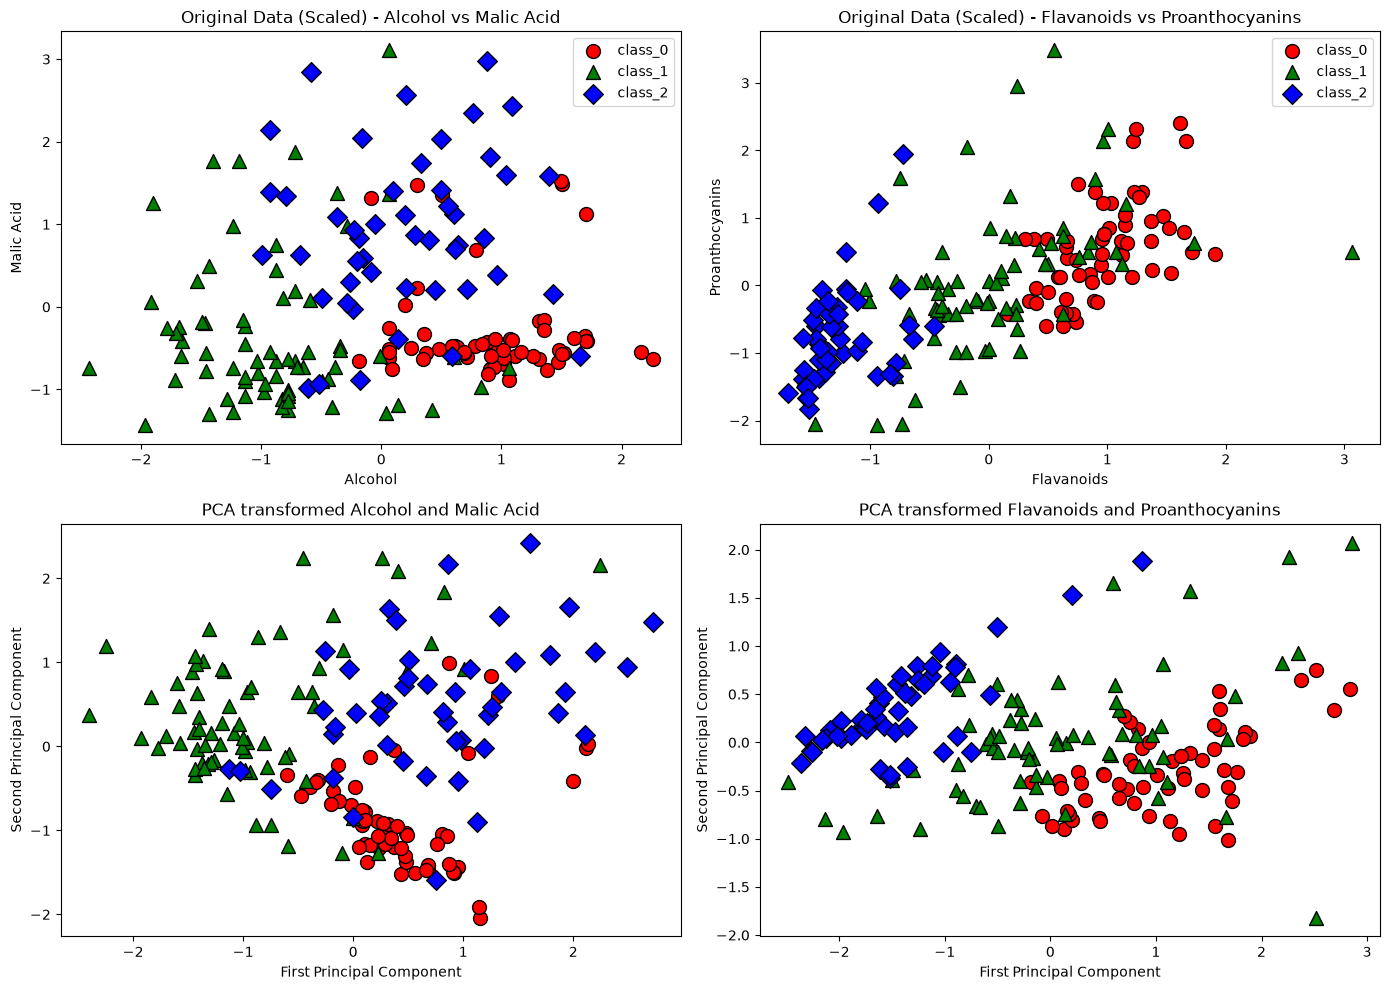

In [3]:
# Choose two features: 'alcohol' and 'malic_acid'
features_1 = ['alcohol', 'malic_acid']
df_wine_subset_1 = df_wine[features_1]
df_wine_subset_1 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_1), columns=features_1)

# Perform PCA on the two features
pca_2d_1 = PCA(n_components=2)
X_pca_2d_1 = pca_2d_1.fit_transform(df_wine_subset_1)

# Choose two different features: 'flavanoids' and 'proanthocyanins'
features_2 = ['flavanoids', 'proanthocyanins']
df_wine_subset_2 = df_wine[features_2]
df_wine_subset_2 = pd.DataFrame(StandardScaler().fit_transform(df_wine_subset_2), columns=features_2)

# Perform PCA on the two different features
pca_2d_2 = PCA(n_components=2)
X_pca_2d_2 = pca_2d_2.fit_transform(df_wine_subset_2)

# Create a figure with four subplots in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original data plot 1 (top left)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,0].scatter(df_wine_subset_1['alcohol'][mask],
                     df_wine_subset_1['malic_acid'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,0].set_xlabel('Alcohol')
axes[0,0].set_ylabel('Malic Acid')
axes[0,0].set_title('Original Data (Scaled) - Alcohol vs Malic Acid')
axes[0,0].legend()

# Original data plot 2 (top right)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[0,1].scatter(df_wine_subset_2['flavanoids'][mask],
                     df_wine_subset_2['proanthocyanins'][mask],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[0,1].set_xlabel('Flavanoids')
axes[0,1].set_ylabel('Proanthocyanins')
axes[0,1].set_title('Original Data (Scaled) - Flavanoids vs Proanthocyanins')
axes[0,1].legend()

# PCA plot 1 (bottom left)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,0].scatter(X_pca_2d_1[mask, 0], 
                     X_pca_2d_1[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,0].set_xlabel('First Principal Component')
axes[1,0].set_ylabel('Second Principal Component')
axes[1,0].set_title('PCA transformed Alcohol and Malic Acid')



# PCA plot 2 (bottom right)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = target_wine == i
    axes[1,1].scatter(X_pca_2d_2[mask, 0],
                     X_pca_2d_2[mask, 1],
                     marker=shape, c=color, edgecolor='k', s=100,
                     label=wine.target_names[i])
axes[1,1].set_xlabel('First Principal Component')
axes[1,1].set_ylabel('Second Principal Component')
axes[1,1].set_title('PCA transformed Flavanoids and Proanthocyanins')



plt.tight_layout()
plt.show()

### Best Practices for PCA:
1. Always scale your data before applying PCA  
   因為 PCA 找的是「資料變異（variance）最大的方向」，如果不同 Feature 的數值尺度差很多，數值大的 Feature 很容易主導 PCA。
2. Check explained variance ratio to determine number of components
3. Use PCA for:
   - Dimensionality reduction
   - Feature extraction
   - Data visualization
   
### Common Pitfalls:
- Not scaling data before PCA
- Using PCA when interpretability is important 當你需要找出原始原因，不要混合因素的時候，不要用PCA
- Keeping too few or too many components

In [4]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==========================================
# 1. 載入 Wine Dataset
# ==========================================
wine = load_wine()

X = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

print("原始 Feature 數量：", X.shape[1])


# ==========================================
# 2. PCA 前先做 StandardScaler
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ==========================================
# 3. 執行 PCA
# ==========================================
# 先不設定 n_components
# 讓 PCA 把所有 Principal Components 都算出來
pca = PCA()

X_pca = pca.fit_transform(X_scaled)


# ==========================================
# 4. 每一個 PC 各自可以解釋多少變異
# ==========================================
explained_ratio = pca.explained_variance_ratio_

print("每個 PC 的 Explained Variance Ratio：")
print(explained_ratio)


# ==========================================
# 5. 計算累積 Explained Variance Ratio
# ==========================================
cumulative_ratio = np.cumsum(explained_ratio)


# ==========================================
# 6. 整理成 DataFrame，方便觀察
# ==========================================
variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_ratio))],

    # 每一個 PC 自己解釋多少
    "Explained Variance": explained_ratio,

    # 從 PC1 累積到目前為止解釋多少
    "Cumulative Variance": cumulative_ratio
})

display(variance_df)

原始 Feature 數量： 13
每個 PC 的 Explained Variance Ratio：
[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


,PC,Explained Variance,Cumulative Variance
0,PC1,0.361988,0.361988
1,PC2,0.192075,0.554063
2,PC3,0.111236,0.665300
3,PC4,0.070690,0.735990
4,PC5,0.065633,0.801623
5,PC6,0.049358,0.850981
6,PC7,0.042387,0.893368
7,PC8,0.026807,0.920175
8,PC9,0.022222,0.942397
9,PC10,0.019300,0.961697


## Linear Discriminant Analysis (LDA)

LDA is a *supervised* dimensionality reduction technique that finds linear combinations of features that best separate classes.   
如何可以讓分類的結果分得更開，就怎麼組合元素

### Key Concepts:
- Maximizes class separability
- Can be used for both dimensionality reduction and classification
- Takes class labels into account (supervised)

### Getting ready
We will use the same Wine dataset used previously, so we do not have to load it again.

### How to do it...

As we saw with PCA, LDA only requires loading a single scikit-learn class to perform it on your dataset. We will also be using the `Pipeline()` class to string together our scaling prior to applying LDA.

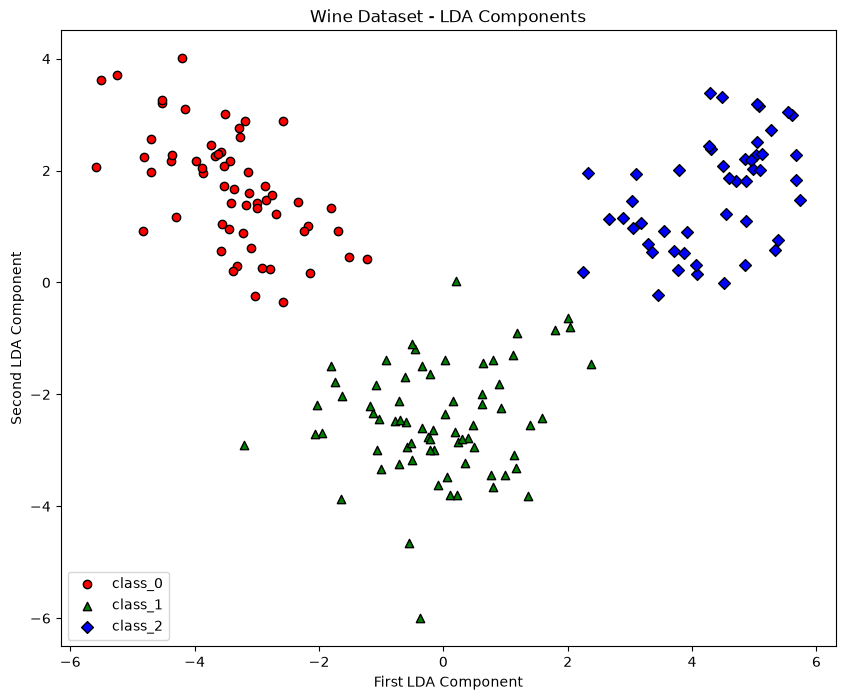

In [5]:
# Load libraries
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Split wine dataset by features and target
X_wine, y_wine = wine.data, wine.target

# Create LDA pipeline for wine dataset
lda_pipeline_wine = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2))  
    # min(n_features, n_classes - 1) for wine dataset is 2 三個類別的中心點之間，最多只有 2 個獨立的分離方向。
])

# Fit and transform the wine data
# 同時考慮 x和y
X_lda_wine = lda_pipeline_wine.fit_transform(X_wine, y_wine)

# Visualize LDA transformation for wine dataset
plt.figure(figsize=(10, 8))

# Define markers and colors for each class
shapes = ['o', '^', 'D']
colors = ['r', 'g', 'b']

# Plot each class with different marker and color
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()
plt.show()

### How it works...

LDA is a supervised technique that seeks to find a linear combination of features that best separates two or more classes. While both PCA and LDA are used for dimensionality reduction, they have distinct objectives and methodologies. When visualized, both PCA and LDA can be similar in appearance depending on the dataset it’s applied to.

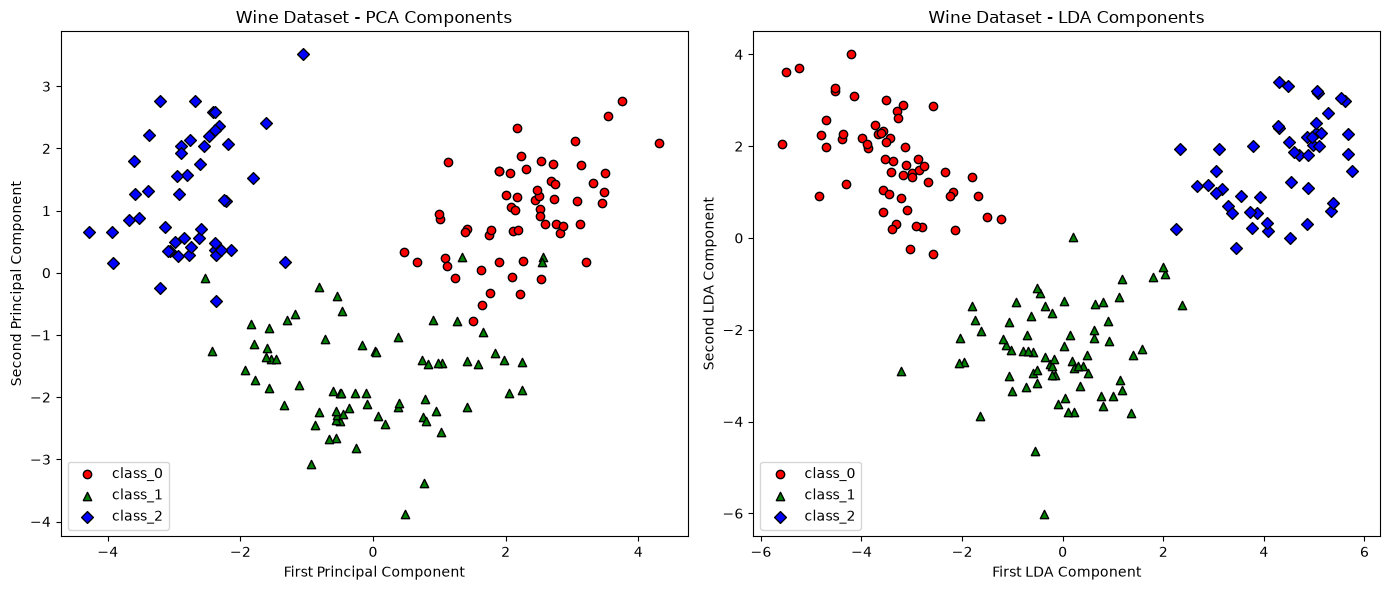

In [6]:
# Create side-by-side plots
plt.figure(figsize=(14, 6))

plt.subplot(121)
shapes = ['o', '^', 'D'] 
colors = ['r', 'g', 'b']

for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Wine Dataset - PCA Components')
plt.legend()

plt.subplot(122)
for i, (shape, color) in enumerate(zip(shapes, colors)):
    mask = y_wine == i
    plt.scatter(X_lda_wine[mask, 0], X_lda_wine[mask, 1],
               c=color, marker=shape, edgecolor='black',
               label=wine.target_names[i])

plt.xlabel('First LDA Component')
plt.ylabel('Second LDA Component')
plt.title('Wine Dataset - LDA Components')
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 建立左右兩張子圖
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        'Wine Dataset - PCA Components',
        'Wine Dataset - LDA Components'
    )
)

# Plotly marker 樣式
symbols = ['circle', 'triangle-up', 'diamond']
colors = ['red', 'green', 'blue']

# 左邊：PCA
for i, (symbol, color) in enumerate(zip(symbols, colors)):
    mask = y_wine == i

    fig.add_trace(
        go.Scatter(
            x=X_pca[mask, 0],
            y=X_pca[mask, 1],
            mode='markers',
            name=wine.target_names[i],
            legendgroup=str(i),

            marker=dict(
                symbol=symbol,
                color=color,
                size=9,
                line=dict(
                    color='black',
                    width=1
                )
            )
        ),
        row=1,
        col=1
    )

# 右邊：LDA
for i, (symbol, color) in enumerate(zip(symbols, colors)):
    mask = y_wine == i

    fig.add_trace(
        go.Scatter(
            x=X_lda_wine[mask, 0],
            y=X_lda_wine[mask, 1],
            mode='markers',
            name=wine.target_names[i],
            legendgroup=str(i),

            # 避免 Legend 重複出現
            showlegend=False,

            marker=dict(
                symbol=symbol,
                color=color,
                size=9,
                line=dict(
                    color='black',
                    width=1
                )
            )
        ),
        row=1,
        col=2
    )

# X / Y 軸標題
fig.update_xaxes(
    title_text='First Principal Component',
    row=1,
    col=1
)

fig.update_yaxes(
    title_text='Second Principal Component',
    row=1,
    col=1
)

fig.update_xaxes(
    title_text='First LDA Component',
    row=1,
    col=2
)

fig.update_yaxes(
    title_text='Second LDA Component',
    row=1,
    col=2
)

# 整體圖表設定
fig.update_layout(
    width=1200,
    height=550,
    title='PCA vs LDA - Wine Dataset'
)

fig.show()

### Best Practices for LDA:
1. Scale features before applying LDA
2. Use when class separation is important
3. Check assumptions (normal distribution, homoscedasticity)

### Common Pitfalls:
- Using LDA with highly imbalanced classes  類別數量差距太大時，要小心使用 LDA。
- Applying to non-normally distributed data

## t-SNE for Data Visualization

t-SNE is a non-linear dimensionality reduction technique particularly well-suited for visualization of high-dimensional data.  
利用降維的方法 把高維的資料轉成二維 看看同一群的資料是否長得很像

### Key Concepts:
- Preserves local structure of the data
- Non-linear transformation
- Particularly good for visualization

### Getting ready
For our t-SNE demonstration, we'll be using a different dataset: another "famous" machine learning dataset called **MNIST** which consists of images of handwritten digits 0-9. From UCI Machine Learning Repository: *"We used preprocessing programs made available by NIST to extract normalized bitmaps of handwritten digits from a preprinted form. From a total of 43 people, 30 contributed to the training set and different 13 to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of 4x4 and the number of on pixels are counted in each block. This generates an input matrix of 8x8 where each element is an integer in the range 0..16. This reduces dimensionality and gives invariance to small distortions."*

In [8]:
# Load libraries
from sklearn.datasets import load_digits

# 下面我們要把64維資料變成2維
# Load dataset
digits = load_digits()
digits 

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64)),
 'target': array([0, 1, 2, ..., 8, 9, 8], shape=(1797,)),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7'

1


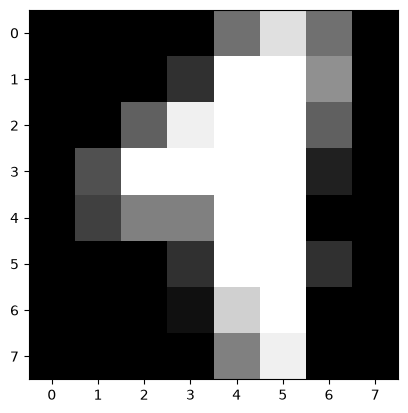

In [9]:
import matplotlib.pyplot as plt

print(digits.target[210])
plt.imshow(digits.images[210], cmap='gray')

plt.show()



### How to do it...

Again, we will use the Pipeline() class to sequentially apply data scaling prior to t-SNE.

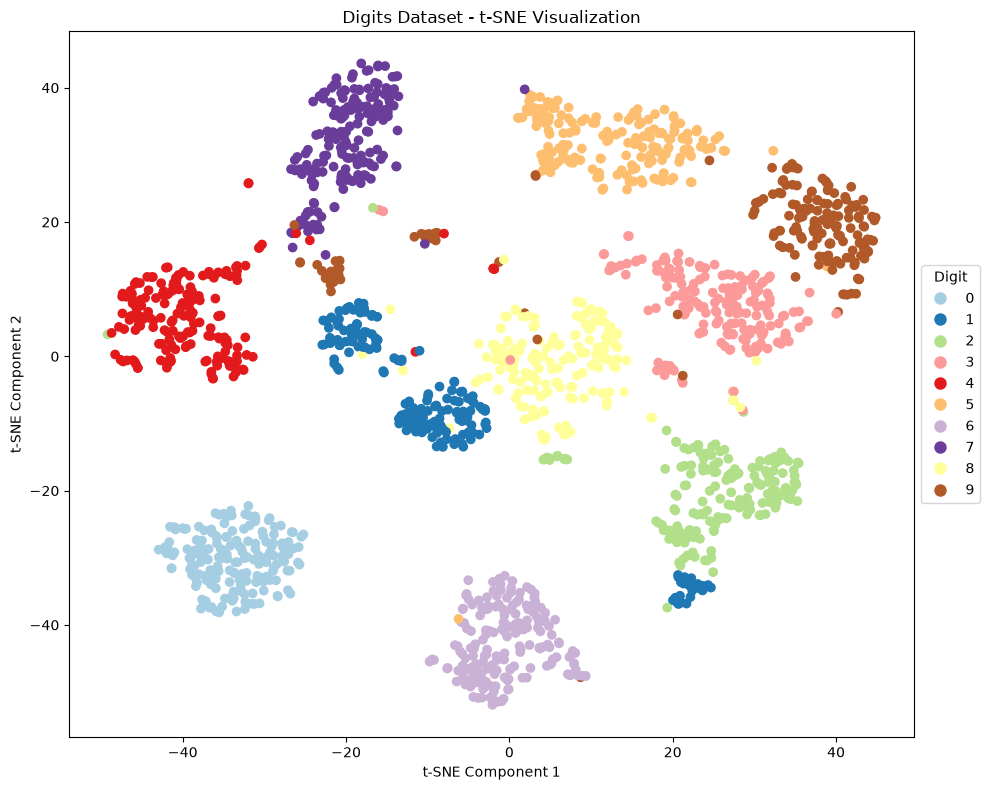

In [10]:
# Load libraries
from sklearn.manifold import TSNE

# Create t-SNE pipeline
tsne_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('tsne', TSNE(n_components=2, random_state=2024))
])

# Fit and transform the digits data
X_tsne = tsne_pipeline.fit_transform(digits.data)
# Visualize t-SNE results
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=digits.target, cmap='Paired', label=digits.target)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Digits Dataset - t-SNE Visualization')

# Create legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                             markerfacecolor=plt.cm.Paired(i/9), 
                             label=str(i), markersize=10)
                  for i in range(10)]
plt.legend(handles=legend_elements, title='Digit', loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()